In [1]:
# M7.1 -- Plotting with the .plot() accessor 
# the .plot() accessor wraps the Matplotlib library
# good for quickly visualizing data

# the .plot() pattern
# df["column"].plot(kind="line")
# df.plot(x="month",
#       y="spend",
#         kind=bar)

# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# create the data
df = pd.DataFrame({
    "month":    ["Jan","Feb","Mar","Apr","May","Jun"] * 3,
    "supplier": ["Acme"]*6 + ["GlobalCo"]*6 + ["FastParts"]*6,
    "spend":    [1500,1800,1200,2100,1700,2000,
                 2200,1900,2400,2000,2300,2100,
                 800,950,1100,750,900,1050],
    "otd_rate": [80,90,70,100,90,100,
                 90,80,100,90,100,90,
                 70,80,90,70,80,90]
})
print(df)

   month   supplier  spend  otd_rate
0    Jan       Acme   1500        80
1    Feb       Acme   1800        90
2    Mar       Acme   1200        70
3    Apr       Acme   2100       100
4    May       Acme   1700        90
5    Jun       Acme   2000       100
6    Jan   GlobalCo   2200        90
7    Feb   GlobalCo   1900        80
8    Mar   GlobalCo   2400       100
9    Apr   GlobalCo   2000        90
10   May   GlobalCo   2300       100
11   Jun   GlobalCo   2100        90
12   Jan  FastParts    800        70
13   Feb  FastParts    950        80
14   Mar  FastParts   1100        90
15   Apr  FastParts    750        70
16   May  FastParts    900        80
17   Jun  FastParts   1050        90


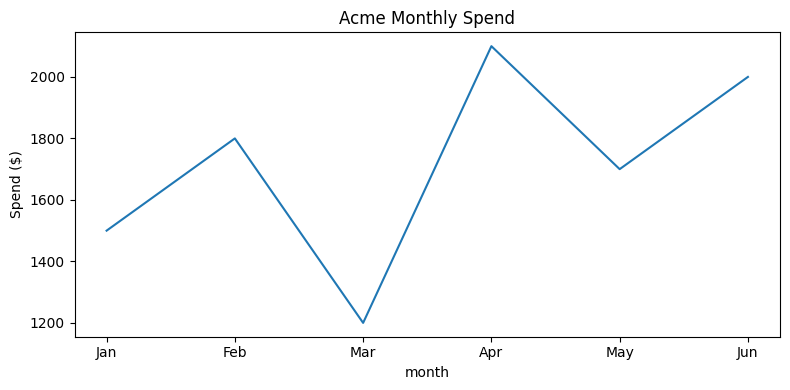

In [2]:
# Exercise 2: Plot Acme's Montly Spend as a Line Chart
# note: when Pandas calls .plot()
# it creates a matplotlib figure
# plt gives you direct access to this figure to add labels, titles, and formatting that .plot() cant handle itself
acme = df[df["supplier"] == "Acme"].set_index("month")
acme["spend"].plot(kind="line",
                   title="Acme Monthly Spend",
                   figsize=(8,4))
plt.ylabel("Spend ($)")
plt.tight_layout() # a software eng practice to auto adjust spacing so labels and titles dont get cut off
plt.show()

# standard .plot() path to follow
# df.plot(...)          # create the chart
# plt.title("...")      # optional — add/override title
# plt.xlabel("...")     # label x axis
# plt.ylabel("...")     # label y axis
# plt.tight_layout()   # fix spacing
# plt.show()           # render it

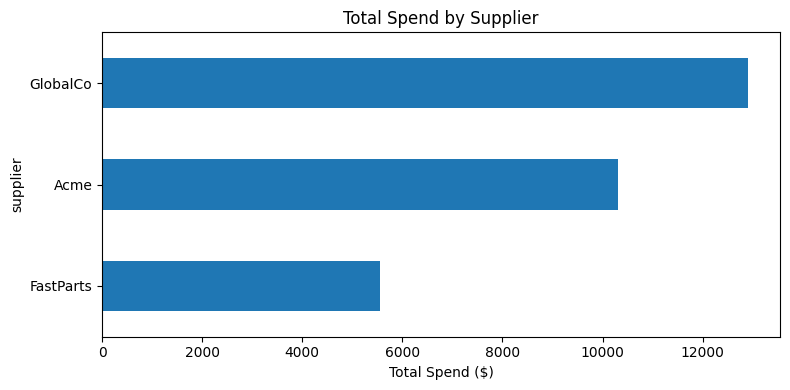

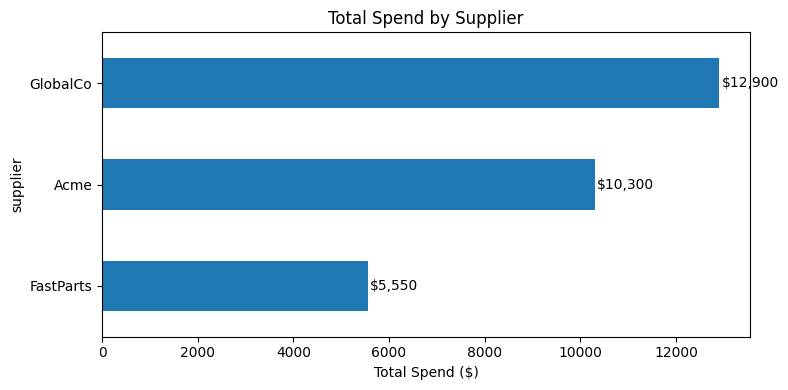

In [3]:
# Exercise 3: Bar Chart
# Plot total spend by supplier 
supplier_total = (
    df
    .groupby(by="supplier")["spend"]
    .sum()
    .sort_values(ascending=True)
)

# plot
supplier_total.plot(
    kind="barh",
    title="Total Spend by Supplier",
    figsize=(8,4)
)
plt.xlabel("Total Spend ($)")
plt.tight_layout()
plt.show()

# optional and advanced
# add data labels
# create the chart and capture the axes object
ax = supplier_total.plot(
    kind="barh",
    title="Total Spend by Supplier",
    figsize=(8, 4)
)

# add data labels at the outside end of each bar
for bar in ax.patches:
    ax.text(
        bar.get_width() + 50,        # x position — just past the end of the bar
        bar.get_y() + bar.get_height() / 2,   # y position — center of the bar
        f"${bar.get_width():,.0f}",  # label text — formatted as currency
        va="center",                 # vertical alignment
        ha="left"                    # horizontal alignment
    )

plt.xlabel("Total Spend ($)")
plt.tight_layout()
plt.show()

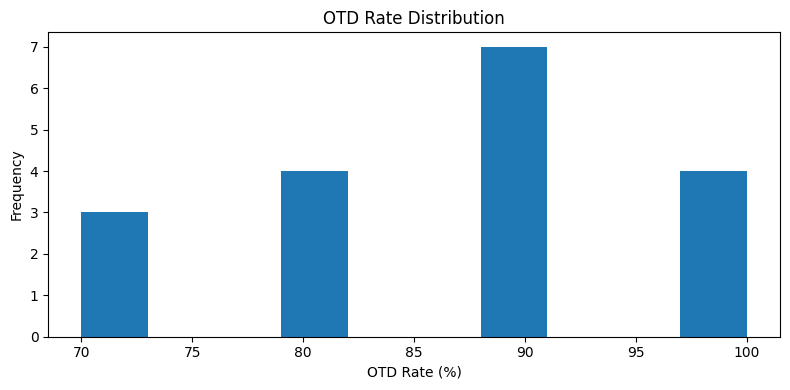

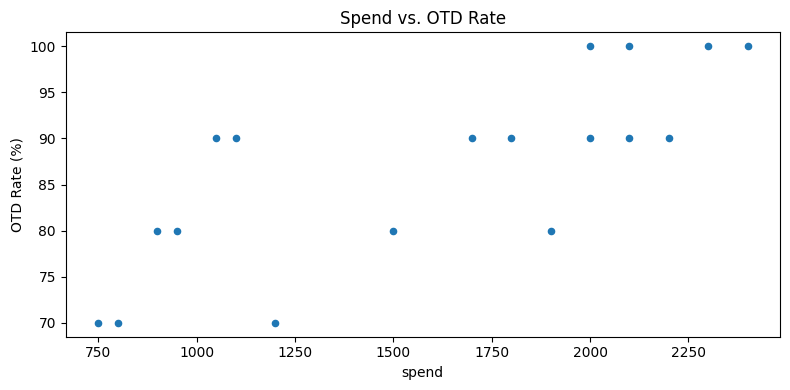

In [4]:
# Exercise 4: histogram and scatterplot

# Plot a histogram of otd_rate across all rows
# select the otd_rate column as a series
otd_rate = df["otd_rate"]
(
    df["otd_rate"]
    .plot(
        kind="hist",
        title="OTD Rate Distribution",
        figsize=(8,4)
    )
)
plt.xlabel("OTD Rate (%)")
plt.tight_layout()
plt.show()

# Plot a scatter of spend vs otd_rate 
# when would you use .plot() vs Plotly in a SC analytics workflow?
(
    df
    .plot(
        x="spend",
        y="otd_rate",
        kind="scatter",
        title="Spend vs. OTD Rate",
        figsize=(8,4)
    )
)
plt.xlabel=("Spend ($)")
plt.ylabel("OTD Rate (%)")
plt.tight_layout()
plt.show()